In [1]:
# ── Cell 0.1: Imports ─────────────────────────────────────────────────────────
import os
import logging
import warnings
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

Importing plotly failed. Interactive plots will not work.


In [2]:
# ── Cell 0.2: Style & Paths ───────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 11
plt.rcParams['axes.titlesize'] = 13

cwd = os.getcwd()
if os.path.basename(cwd) == 'notebooks':
    FIGURES_PATH   = os.path.join("..", "outputs", "figures")
    PROCESSED_PATH = os.path.join("..", "data", "processed")
    ENV_PATH       = "../.env"
else:
    FIGURES_PATH   = os.path.join("outputs", "figures")
    PROCESSED_PATH = os.path.join("data", "processed")
    ENV_PATH       = ".env"

os.makedirs(FIGURES_PATH, exist_ok=True)
print(f"✓ Figures  → {os.path.abspath(FIGURES_PATH)}")
print(f"✓ Outputs  → {os.path.abspath(PROCESSED_PATH)}")

✓ Figures  → C:\Users\jabez\Documents\ai-job-displacement-observatory\outputs\figures
✓ Outputs  → C:\Users\jabez\Documents\ai-job-displacement-observatory\data\processed


In [3]:
# ── Cell 0.3: DB Connection & Constants ──────────────────────────────────────
load_dotenv(ENV_PATH)

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

with engine.connect() as conn:
    count = conn.execute(text("SELECT COUNT(*) FROM bls_oews")).scalar()
print(f"✓ Connected. bls_oews: {count:,} rows")

DETAILED_FILTER   = "RIGHT(occ_code, 1) != '0'"
TRAIN_YEARS       = list(range(2018, 2024))
TEST_YEARS        = [2024, 2025]
FORECAST_YEARS    = [2026, 2027]
TOP_N             = 20
RANDOM_STATE      = 42

✓ Connected. bls_oews: 1,182,597 rows


In [32]:
# ── Cell 0.4: Load Part 5 Outputs ────────────────────────────────────────────
# The occupation-level risk index from Part 5 is used for context and validation.
occ_index_path = os.path.join(PROCESSED_PATH, "occupation_risk_index.csv")
df_occ_index   = pd.read_csv(occ_index_path)

print(f"Occupation risk index loaded: {len(df_occ_index):,} rows")
print(df_occ_index[['occ_code', 'occ_title', 'risk_index']].head(3).to_string(index=False))

Occupation risk index loaded: 938 rows
occ_code                       occ_title  risk_index
 11-1011                Chief Executives    0.319709
 11-1011                Chief Executives    0.302625
 11-1021 General and Operations Managers    0.404252


## Section 1 — Prophet: Employment Forecasting

**Library:** Facebook Prophet (now maintained as open-source `prophet`)
**Task:** Forecast national employment per occupation from 2026–2027
**Train:** 2018–2023  |  **Test (holdout):** 2024–2025  |  **Forecast:** 2026–2027

### Why Prophet for Annual Employment Data?
Prophet is a decomposable time series model (trend + seasonality + holidays) designed
for business time series. With annual BLS data (only 8 points), we disable all
seasonality detection and use it purely as a **Bayesian trend model**.

Key settings for annual data:
- `yearly_seasonality=False` — can't detect annual patterns in annual data
- `changepoint_prior_scale=0.1` — conservative; prevents overfitting on 6 training points
- `holidays=covid_anomaly` — flags 2020 so the COVID shock doesn't distort the trend

### Evaluation Strategy
Train on 2018–2023 (6 points), evaluate on 2024–2025 (2 held-out points).
With only 2 test points, RMSE is directional, not statistically robust — but it
confirms the model isn't dramatically wrong. MAPE (Mean Absolute Percentage Error)
is more interpretable since it normalizes by occupation size.

In [33]:
# ── Cell 1.1: Load Employment Time Series ────────────────────────────────────
df_emp = pd.read_sql(f"""
    SELECT year, occ_code, occ_title, tot_emp
    FROM bls_oews
    WHERE data_type = 'national'
      AND {DETAILED_FILTER}
      AND tot_emp IS NOT NULL
    ORDER BY occ_code, year
""", engine)

df_emp['tot_emp'] = pd.to_numeric(df_emp['tot_emp'], errors='coerce')
df_emp = df_emp.dropna(subset=['tot_emp'])

print(f"Employment time series rows: {len(df_emp):,}")
print(f"Years covered:   {sorted(df_emp['year'].unique())}")
print(f"Occupations:     {df_emp['occ_code'].nunique():,}")

Employment time series rows: 6,471
Years covered:   [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Occupations:     929


In [34]:
# ── Cell 1.2: Select Top 20 Occupations by 2025 Employment ───────────────────
# We forecast the largest occupations because they have the most complete
# time series (less suppression) and represent the greatest number of workers.

top_occs = (
    df_emp[df_emp['year'] == 2025]
    .nlargest(TOP_N, 'tot_emp')[['occ_code', 'occ_title', 'tot_emp']]
    .reset_index(drop=True)
)

print(f"Top {TOP_N} occupations selected for Prophet forecasting:\n")
print(top_occs[['occ_title', 'tot_emp']].to_string(index=False))

Top 20 occupations selected for Prophet forecasting:

                                                                      occ_title   tot_emp
                                                            Retail Salespersons 3897860.0
                                                  Fast Food and Counter Workers 3854050.0
                                                General and Operations Managers 3503020.0
                                                              Registered Nurses 3379720.0
                                                                       Cashiers 3089410.0
                         Laborers and Freight, Stock, and Material Movers, Hand 2950280.0
                                                     Stockers and Order Fillers 2833810.0
                                               Customer Service Representatives 2595750.0
                                                         Office Clerks, General 2464940.0
                                              

In [35]:
# ── Cell 1.3: Prophet Helper Functions ───────────────────────────────────────
# COVID anomaly — tells Prophet to treat 2020 as an external shock,
# not a structural change in the underlying employment trend
covid_anomaly = pd.DataFrame({
    'holiday':       'covid_anomaly',
    'ds':            pd.to_datetime(['2020-07-01']),
    'lower_window':  0,
    'upper_window':  0,
})


def prepare_prophet_df(occ_code):
    """Format one occupation's employment series as (ds, y) for Prophet."""
    df_occ = df_emp[df_emp['occ_code'] == occ_code].copy()
    # July 1: approximate midpoint of BLS's survey reference period
    df_occ['ds'] = pd.to_datetime(df_occ['year'].astype(str) + '-07-01')
    df_occ['y']  = df_occ['tot_emp']
    return df_occ[['ds', 'y']].sort_values('ds').reset_index(drop=True)


def fit_and_forecast(occ_code, occ_title):
    """Fit Prophet on training years and forecast through 2027."""
    df_prophet = prepare_prophet_df(occ_code)
    df_train   = df_prophet[df_prophet['ds'].dt.year.isin(TRAIN_YEARS)]

    model = Prophet(
        holidays              = covid_anomaly,
        yearly_seasonality    = False,
        weekly_seasonality    = False,
        daily_seasonality     = False,
        changepoint_prior_scale = 0.1,
        uncertainty_samples   = 500,
    )
    model.fit(df_train)

    # All historical years + forecast years
    all_years = sorted(
        set(df_prophet['ds'].dt.year.tolist() + FORECAST_YEARS)
    )
    future   = pd.DataFrame({'ds': pd.to_datetime([f'{y}-07-01' for y in all_years])})
    forecast = model.predict(future)
    forecast['occ_code']    = occ_code
    forecast['occ_title']   = occ_title
    forecast['year']        = forecast['ds'].dt.year

    # Merge in actual values for evaluation
    forecast = forecast.merge(
        df_prophet.rename(columns={'y': 'actual'}),
        on='ds', how='left'
    )

    # Holdout evaluation on 2024-2025
    df_eval  = forecast[forecast['year'].isin(TEST_YEARS)].dropna(subset=['actual'])
    rmse, mape = np.nan, np.nan
    if len(df_eval) > 0:
        rmse = np.sqrt(((df_eval['actual'] - df_eval['yhat']) ** 2).mean())
        mape = (np.abs(df_eval['actual'] - df_eval['yhat']) / df_eval['actual']).mean() * 100

    return forecast, rmse, mape


print("✓ Prophet helper functions defined.")

✓ Prophet helper functions defined.


In [36]:
# ── Cell 1.4: Run Prophet for All Top 20 Occupations ─────────────────────────
# This cell takes 1-3 minutes. Prophet fits a Bayesian model per occupation.

all_forecasts    = []
evaluation_rows  = []

for _, row in top_occs.iterrows():
    occ_code, occ_title = row['occ_code'], row['occ_title']
    df_prophet = prepare_prophet_df(occ_code)

    if len(df_prophet) < 4:
        print(f"  SKIP: {occ_title[:40]} — too few data points")
        continue

    forecast, rmse, mape = fit_and_forecast(occ_code, occ_title)
    all_forecasts.append(forecast)
    evaluation_rows.append({
        'occ_code':  occ_code,
        'occ_title': occ_title,
        'rmse':      rmse,
        'mape_pct':  mape
    })
    print(f"  ✓ {occ_title[:45]:<46}  RMSE: {rmse:>10,.0f}   MAPE: {mape:.1f}%")

df_forecasts  = pd.concat(all_forecasts, ignore_index=True)
df_evaluation = pd.DataFrame(evaluation_rows)

print(f"\nForecasting complete: {len(evaluation_rows)} occupations")
print(f"Median holdout MAPE: {df_evaluation['mape_pct'].median():.1f}%")

  ✓ Retail Salespersons                             RMSE:    201,193   MAPE: 5.0%
  ✓ Fast Food and Counter Workers                   RMSE:    611,347   MAPE: 15.8%
  ✓ General and Operations Managers                 RMSE:    457,656   MAPE: 12.0%
  ✓ Registered Nurses                               RMSE:     79,055   MAPE: 2.3%
  ✓ Cashiers                                        RMSE:    162,619   MAPE: 5.2%
  ✓ Laborers and Freight, Stock, and Material Mov   RMSE:    215,075   MAPE: 6.9%
  ✓ Stockers and Order Fillers                      RMSE:    421,380   MAPE: 14.8%
  ✓ Customer Service Representatives                RMSE:    266,951   MAPE: 9.7%
  ✓ Office Clerks, General                          RMSE:     61,147   MAPE: 2.5%
  ✓ Waiters and Waitresses                          RMSE:    425,168   MAPE: 18.5%
  ✓ Janitors and Cleaners, Except Maids and House   RMSE:     76,377   MAPE: 3.3%
  ✓ Heavy and Tractor-Trailer Truck Drivers         RMSE:     95,356   MAPE: 4.2%
  ✓ Secretar

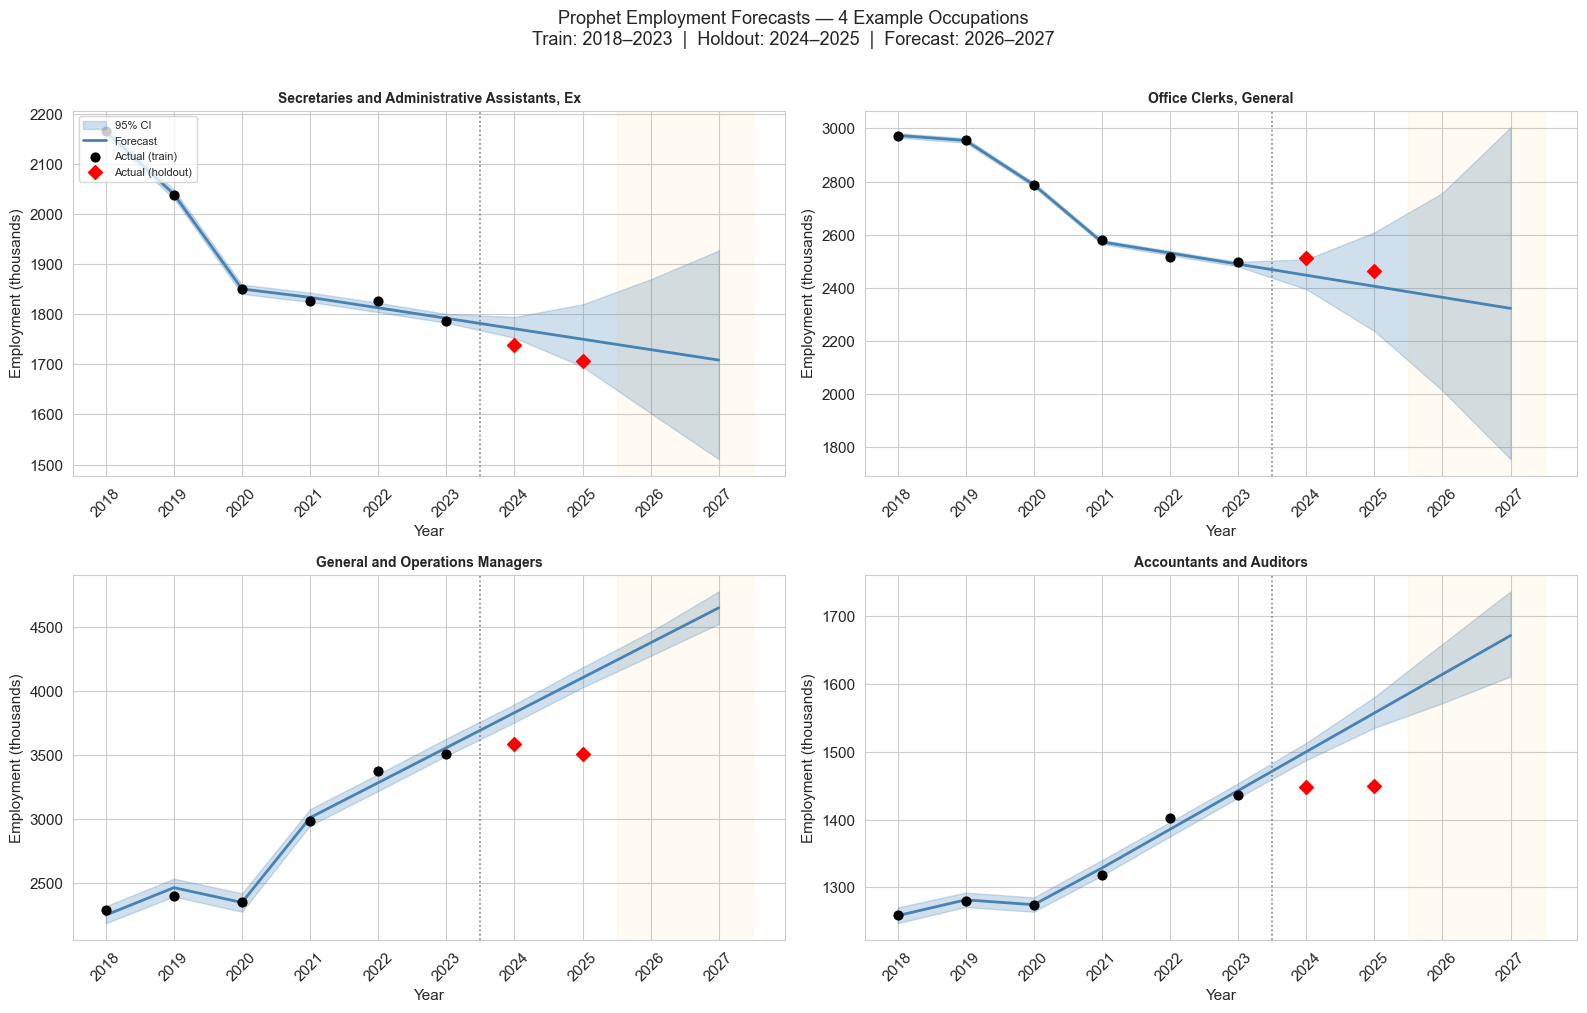

✓ Saved: p6_01_prophet_example_forecasts.png


In [37]:
# ── Cell 1.5: Chart — Example Prophet Forecasts ───────────────────────────────
# Show 4 occupations with different risk profiles to illustrate the model.
# Pick 2 declining + 2 growing occupations based on emp_cagr from Part 5.

example_occs = (
    df_occ_index
    .merge(top_occs[['occ_code']], on='occ_code', how='inner')
    .dropna(subset=['emp_cagr'])
)
declining_2  = example_occs.nsmallest(2, 'emp_cagr')['occ_code'].tolist()
growing_2    = example_occs.nlargest(2,  'emp_cagr')['occ_code'].tolist()
plot_occs    = declining_2 + growing_2

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, occ_code in enumerate(plot_occs):
    ax       = axes[i]
    df_plot  = df_forecasts[df_forecasts['occ_code'] == occ_code]
    occ_title = df_plot['occ_title'].iloc[0]

    # Confidence interval
    ax.fill_between(df_plot['year'], df_plot['yhat_lower'] / 1000,
                    df_plot['yhat_upper'] / 1000,
                    alpha=0.25, color='steelblue', label='95% CI')

    # Forecast line
    ax.plot(df_plot['year'], df_plot['yhat'] / 1000,
            color='steelblue', linewidth=2, label='Forecast')

    # Actual data points
    actuals = df_plot.dropna(subset=['actual'])
    train_actual = actuals[actuals['year'].isin(TRAIN_YEARS)]
    test_actual  = actuals[actuals['year'].isin(TEST_YEARS)]

    ax.scatter(train_actual['year'], train_actual['actual'] / 1000,
               color='black', zorder=5, s=40, label='Actual (train)')
    ax.scatter(test_actual['year'],  test_actual['actual']  / 1000,
               color='red',   zorder=5, s=50, marker='D', label='Actual (holdout)')

    # Train/forecast boundary
    ax.axvline(2023.5, color='gray', linestyle=':', linewidth=1.2)
    ax.axvspan(2025.5, df_plot['year'].max() + 0.5, alpha=0.05, color='orange')

    ax.set_title(f"{occ_title[:45]}", fontsize=10, fontweight='bold')
    ax.set_ylabel("Employment (thousands)")
    ax.set_xlabel("Year")
    ax.set_xticks(sorted(df_plot['year'].unique()))
    ax.tick_params(axis='x', rotation=45)
    if i == 0:
        ax.legend(fontsize=8, loc='upper left')

fig.suptitle("Prophet Employment Forecasts — 4 Example Occupations\n"
             "Train: 2018–2023  |  Holdout: 2024–2025  |  Forecast: 2026–2027",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p6_01_prophet_example_forecasts.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p6_01_prophet_example_forecasts.png")

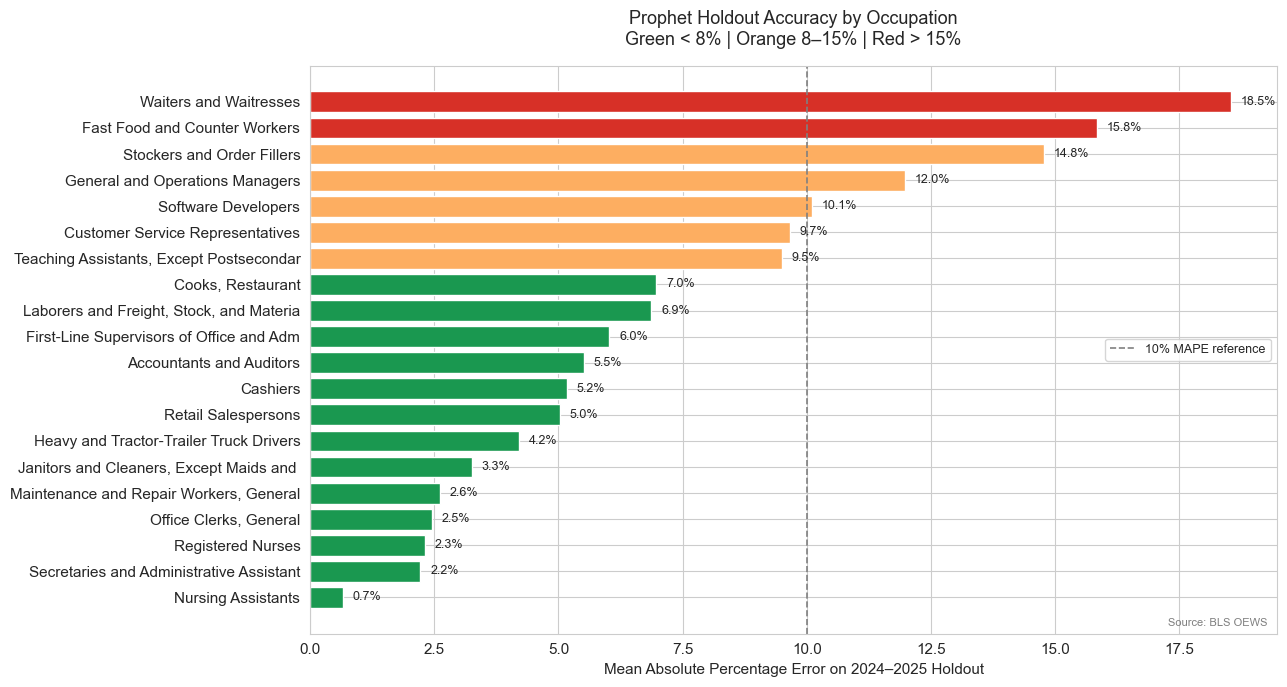

✓ Saved: p6_02_prophet_holdout_mape.png


In [38]:
# ── Cell 1.6: Chart — Holdout MAPE by Occupation ─────────────────────────────
df_eval_plot = df_evaluation.sort_values('mape_pct').copy()
df_eval_plot['short_title'] = df_eval_plot['occ_title'].str[:40]

colors = ['#d73027' if m > 15 else '#fdae61' if m > 8 else '#1a9850'
          for m in df_eval_plot['mape_pct']]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(df_eval_plot['short_title'], df_eval_plot['mape_pct'], color=colors)

ax.axvline(10, color='gray', linestyle='--', linewidth=1.2, label='10% MAPE reference')

for bar, val in zip(bars, df_eval_plot['mape_pct']):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va='center', fontsize=9)

ax.set_xlabel("Mean Absolute Percentage Error on 2024–2025 Holdout")
ax.set_title("Prophet Holdout Accuracy by Occupation\n"
             "Green < 8% | Orange 8–15% | Red > 15%", pad=15)
ax.legend(fontsize=9)
ax.text(0.99, 0.01, "Source: BLS OEWS",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p6_02_prophet_holdout_mape.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p6_02_prophet_holdout_mape.png")

In [39]:
# ── Cell 1.7: Save Employment Forecasts ──────────────────────────────────────
forecast_path = os.path.join(PROCESSED_PATH, "employment_forecasts.csv")
df_forecasts.to_csv(forecast_path, index=False)

print(f"✓ Saved: {os.path.abspath(forecast_path)}")
print(f"  Rows: {len(df_forecasts):,}")
print(f"  Occupations: {df_forecasts['occ_code'].nunique()}")
print(f"  Years covered: {sorted(df_forecasts['year'].unique())}")
print(f"\nSample forecast rows (2026–2027):")
print(df_forecasts[df_forecasts['year'].isin(FORECAST_YEARS)]
      [['occ_title', 'year', 'yhat', 'yhat_lower', 'yhat_upper']]
      .head(6).to_string(index=False))

✓ Saved: C:\Users\jabez\Documents\ai-job-displacement-observatory\data\processed\employment_forecasts.csv
  Rows: 193
  Occupations: 20
  Years covered: [np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026), np.int32(2027)]

Sample forecast rows (2026–2027):
                      occ_title  year         yhat   yhat_lower   yhat_upper
            Retail Salespersons  2026 3.643499e+06 3.048306e+06 4.161953e+06
            Retail Salespersons  2027 3.635928e+06 2.631279e+06 4.419055e+06
  Fast Food and Counter Workers  2026 3.068512e+06 2.710217e+06 3.416779e+06
  Fast Food and Counter Workers  2027 2.972856e+06 2.603340e+06 3.314244e+06
General and Operations Managers  2026 4.375101e+06 4.272572e+06 4.460678e+06
General and Operations Managers  2027 4.648041e+06 4.522532e+06 4.776314e+06


## Section 2 — XGBoost: Predicting Automation Probability from O*NET Data

**Library:** XGBoost (Extreme Gradient Boosting)
**Target variable:** `automation_prob` (Frey & Osborne scores, 0–1)
**Features:** O*NET Importance scores for all ~40 work activities
**Train/test split:** 80% / 20% random split of the 702 scored occupations

### Why This Model?
Frey & Osborne (2013) scored 702 occupations through expert analysis. We now want
to know: *can a machine learning model reproduce those scores using only O*NET task
data?* If yes (R² > 0.65):

1. **It validates our O*NET AI Exposure feature** — the task composition of a job
   genuinely predicts automation risk, not just correlates with it incidentally.
2. **It extends coverage** — we can apply the model to all O*NET occupations,
   generating predicted automation scores for the ~15–20% of BLS occupations that
   Frey-Osborne never scored.
3. **Feature importance** reveals *which O*NET activities actually drive automation
   risk.

### Why XGBoost?
XGBoost handles tabular data with ~40 features and ~700 samples extremely well.
It's robust to correlated features (O*NET activity scores are moderately correlated),
doesn't require feature scaling, and provides native feature importance.

In [40]:
# ── Cell 2.1: Build O*NET Feature Matrix ──────────────────────────────────────
# Load all ~40 O*NET Importance scores and pivot into a wide feature matrix.
# Each occupation becomes a row; each work activity becomes a column.

df_onet_all = pd.read_sql("""
    SELECT onet_soc_code, element_name, data_value
    FROM onet_work_activities
    WHERE scale_id = 'IM' AND data_value IS NOT NULL
""", engine)

df_pivot = df_onet_all.pivot_table(
    index   = 'onet_soc_code',
    columns = 'element_name',
    values  = 'data_value',
    aggfunc = 'mean'
).reset_index()

activity_cols = [c for c in df_pivot.columns if c != 'onet_soc_code']

# Fill any missing cells with that activity's median across all occupations
for col in activity_cols:
    df_pivot[col] = df_pivot[col].fillna(df_pivot[col].median())

df_pivot['occ_code'] = df_pivot['onet_soc_code'].str[:7]

print(f"Feature matrix: {len(df_pivot):,} occupations × {len(activity_cols)} activity features")
print(f"\nActivities used as features:")
for i, act in enumerate(sorted(activity_cols), 1):
    print(f"  {i:>2}. {act}")

Feature matrix: 894 occupations × 41 activity features

Activities used as features:
   1. Analyzing Data or Information
   2. Assisting and Caring for Others
   3. Coaching and Developing Others
   4. Communicating with People Outside the Organization
   5. Communicating with Supervisors, Peers, or Subordinates
   6. Controlling Machines and Processes
   7. Coordinating the Work and Activities of Others
   8. Developing Objectives and Strategies
   9. Developing and Building Teams
  10. Documenting/Recording Information
  11. Drafting, Laying Out, and Specifying Technical Devices, Parts, and Equipment
  12. Establishing and Maintaining Interpersonal Relationships
  13. Estimating the Quantifiable Characteristics of Products, Events, or Information
  14. Evaluating Information to Determine Compliance with Standards
  15. Getting Information
  16. Guiding, Directing, and Motivating Subordinates
  17. Handling and Moving Objects
  18. Identifying Objects, Actions, and Events
  19. Inspec

In [41]:
# ── Cell 2.2: Join to Frey-Osborne Scores & Enrich Features ──────────────────
df_auto = pd.read_sql(
    "SELECT occ_code, automation_prob, education_req FROM automation_scores", engine
)

df_ml = df_pivot.merge(df_auto, on='occ_code', how='inner')

# ── Add Feature: Education Level (ordinal encoding) ───────────────────────────
# Education has a near-monotonic inverse relationship with automation risk.
# Ordinal encoding preserves this ordering — higher number = more education = lower risk.
edu_order = {
    'Less than high school':               0,
    'High school diploma or equivalent':   1,
    'Postsecondary nondegree award':       2,
    'Some college, no degree':             3,
    "Associate's degree":                  4,
    "Bachelor's degree":                   5,
    "Master's degree":                     6,
    'Doctoral or professional degree':     7,
}
df_ml['edu_encoded'] = df_ml['education_req'].map(edu_order)

# If any education labels don't match exactly, fill with the median level
edu_median = df_ml['edu_encoded'].median()
df_ml['edu_encoded'] = df_ml['edu_encoded'].fillna(edu_median)

print(f"Education encoding applied. Null values remaining: {df_ml['edu_encoded'].isna().sum()}")
print(f"\nEducation distribution in training data:")
print(df_ml['education_req'].value_counts().to_string())

# ── Add Feature: Major Occupation Group (label encoded) ───────────────────────
# The 2-digit SOC prefix (e.g. "15" for Computer occupations) captures
# broad structural differences in what kinds of tasks define each field.
df_ml['major_code']         = df_ml['occ_code'].str[:2]
major_codes                 = sorted(df_ml['major_code'].unique())
major_code_map              = {code: i for i, code in enumerate(major_codes)}
df_ml['major_code_encoded'] = df_ml['major_code'].map(major_code_map)

print(f"\nMajor groups represented: {len(major_codes)}")

# ── Final feature set ─────────────────────────────────────────────────────────
extended_feature_cols = activity_cols + ['edu_encoded', 'major_code_encoded']

X = df_ml[extended_feature_cols].values
y = df_ml['automation_prob'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"\nMatched occupations: {len(df_ml):,}")
print(f"Features: {len(extended_feature_cols)} ({len(activity_cols)} O*NET activities + edu + major group)")
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Education encoding applied. Null values remaining: 0

Education distribution in training data:
education_req
High school diploma or equivalent    292
Bachelor's degree                    196
No formal educational credential      87
Associate's degree                    42
Postsecondary nondegree award         38
Master's degree                       32
Doctoral or professional degree       19
Some college, no degree                3

Major groups represented: 22

Matched occupations: 709
Features: 43 (41 O*NET activities + edu + major group)
Train: 567  |  Test: 142


In [42]:
# ── Cell 2.3: Train XGBoost Model ────────────────────────────────────────────
xgb_model = XGBRegressor(
    n_estimators     = 400,
    max_depth        = 5,
    learning_rate    = 0.04,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    random_state     = RANDOM_STATE,
    verbosity        = 0,
)

xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = False
)

y_pred = xgb_model.predict(X_test)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)

print("=== XGBOOST EVALUATION (20% Holdout) ===")
print(f"  RMSE:  {rmse:.4f}  (average prediction error on 0–1 scale)")
print(f"  R²:    {r2:.4f}  (proportion of variance explained)")
print(f"\n  Interpretation:")
print(f"  An RMSE of {rmse:.3f} means predictions are off by ~{rmse*100:.0f} percentage points on average.")
print(f"  R² of {r2:.2f} means O*NET task data + education explains {r2*100:.0f}% of the variance in automation scores.")

=== XGBOOST EVALUATION (20% Holdout) ===
  RMSE:  0.2595  (average prediction error on 0–1 scale)
  R²:    0.5240  (proportion of variance explained)

  Interpretation:
  An RMSE of 0.260 means predictions are off by ~26 percentage points on average.
  R² of 0.52 means O*NET task data + education explains 52% of the variance in automation scores.


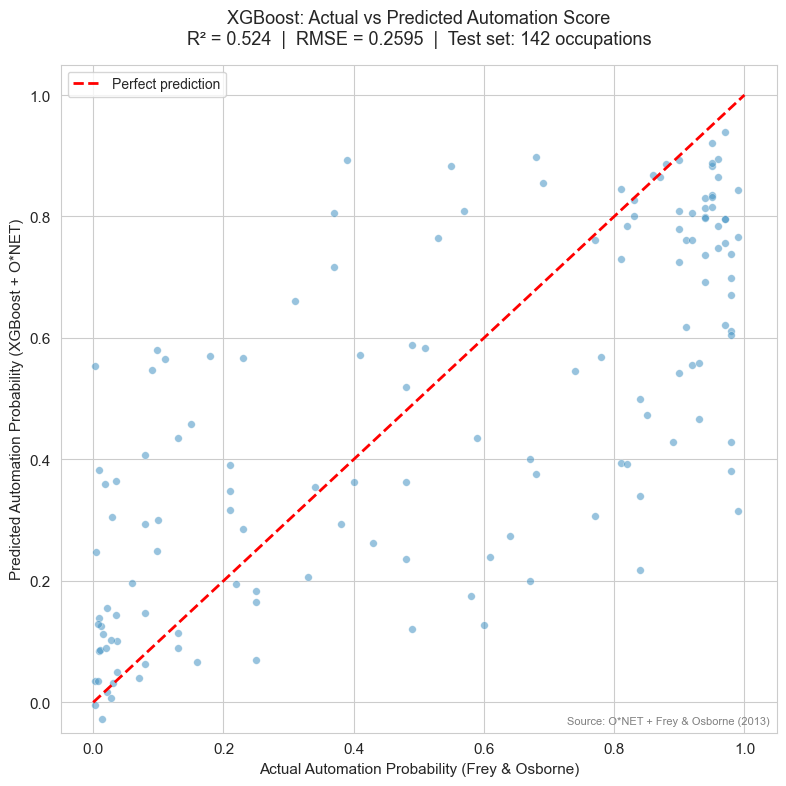

✓ Saved: p6_03_xgb_actual_vs_predicted.png


In [43]:
# ── Cell 2.4: Chart — Actual vs Predicted Automation Probability ──────────────
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred, alpha=0.55, s=30, color='#4393c3', edgecolors='white', linewidths=0.4)
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect prediction')

ax.set_xlabel("Actual Automation Probability (Frey & Osborne)")
ax.set_ylabel("Predicted Automation Probability (XGBoost + O*NET)")
ax.set_title(f"XGBoost: Actual vs Predicted Automation Score\n"
             f"R² = {r2:.3f}  |  RMSE = {rmse:.4f}  |  Test set: {len(y_test)} occupations",
             pad=15)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
ax.text(0.99, 0.01, "Source: O*NET + Frey & Osborne (2013)",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p6_03_xgb_actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p6_03_xgb_actual_vs_predicted.png")

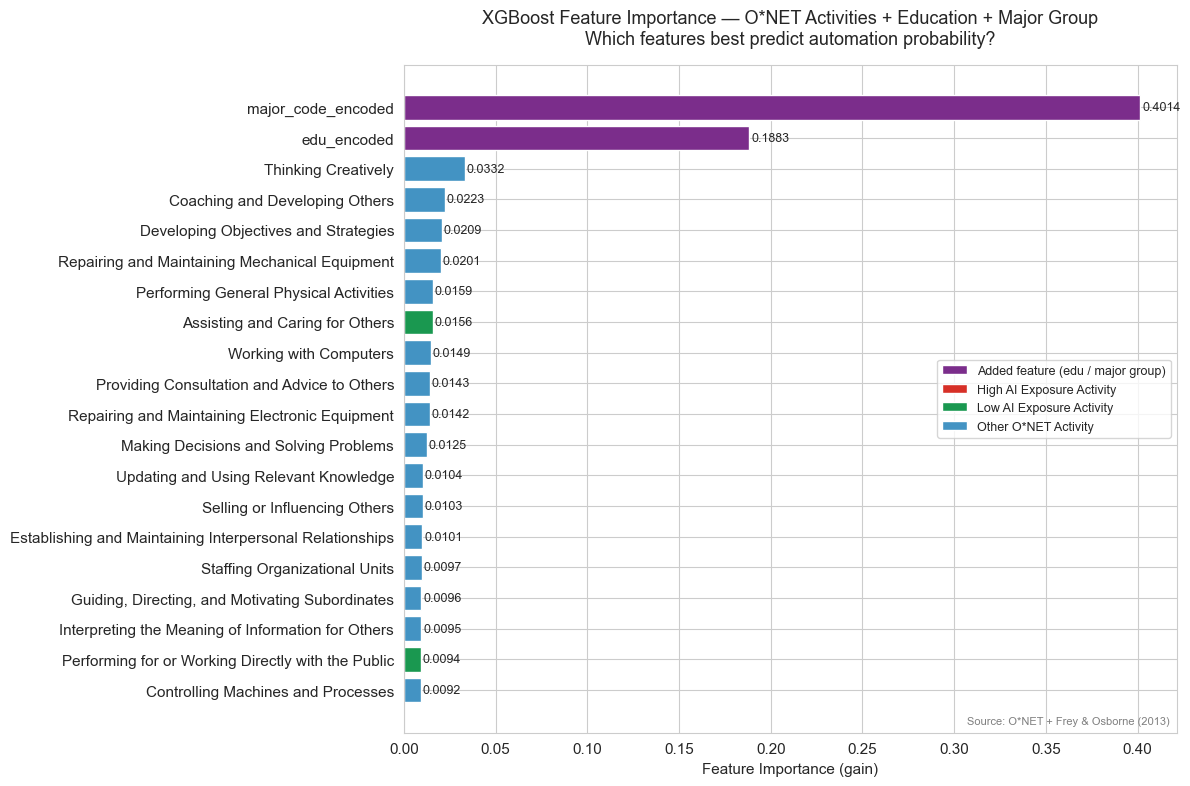

✓ Saved: p6_04_xgb_feature_importance.png


In [44]:
# ── Cell 2.5: Chart — XGBoost Feature Importance ─────────────────────────────
importances = pd.Series(xgb_model.feature_importances_, index=extended_feature_cols)
importances = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))

high_ai = ["Processing Information", "Analyzing Data or Information",
           "Documenting/Recording Information", "Interacting With Computers"]
low_ai  = ["Assisting and Caring for Others",
           "Performing for or Working Directly with the Public",
           "Handling and Moving Objects",
           "Operating Vehicles, Mechanized Devices, or Equipment"]
special = ['edu_encoded', 'major_code_encoded']

colors = []
for feat in importances.index:
    if feat in special:   colors.append('#7b2d8b')   # purple for added features
    elif feat in high_ai: colors.append('#d73027')
    elif feat in low_ai:  colors.append('#1a9850')
    else:                 colors.append('#4393c3')

bars = ax.barh(importances.index, importances.values, color=colors)
ax.invert_yaxis()

for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va='center', fontsize=9)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='#7b2d8b', label='Added feature (edu / major group)'),
    Patch(facecolor='#d73027', label='High AI Exposure Activity'),
    Patch(facecolor='#1a9850', label='Low AI Exposure Activity'),
    Patch(facecolor='#4393c3', label='Other O*NET Activity'),
]
ax.legend(handles=legend_handles, fontsize=9)
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("XGBoost Feature Importance — O*NET Activities + Education + Major Group\n"
             "Which features best predict automation probability?", pad=15)
ax.text(0.99, 0.01, "Source: O*NET + Frey & Osborne (2013)",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/p6_04_xgb_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: p6_04_xgb_feature_importance.png")

In [45]:
# ── Cell 2.6: Predict Automation Scores for Unmatched Occupations ─────────────
df_all_occ = pd.read_sql(f"""
    SELECT DISTINCT occ_code, occ_title
    FROM bls_oews
    WHERE year = 2025 AND data_type = 'national'
      AND {DETAILED_FILTER}
""", engine)

df_scored    = df_auto[['occ_code']].copy()
df_unmatched = df_all_occ[~df_all_occ['occ_code'].isin(df_scored['occ_code'])]

df_unmatched_features = (
    df_pivot[df_pivot['occ_code'].isin(df_unmatched['occ_code'])]
    .copy()
)

print(f"Unmatched occupations (no Frey-Osborne score): {len(df_unmatched):,}")
print(f"Of those, with O*NET features available:       {len(df_unmatched_features):,}")

if len(df_unmatched_features) > 0:
    # Add the same structural features used in training
    df_unmatched_features['major_code']         = df_unmatched_features['occ_code'].str[:2]
    df_unmatched_features['major_code_encoded'] = df_unmatched_features['major_code'].map(major_code_map).fillna(0)
    df_unmatched_features['edu_encoded']        = edu_median  # no edu data for unmatched; use median

    X_new = df_unmatched_features[extended_feature_cols].fillna(0).values
    df_unmatched_features['predicted_automation_prob'] = xgb_model.predict(X_new)
    df_unmatched_features['prediction_source']         = 'xgboost'

    df_xgb_output = df_unmatched_features[
        ['occ_code', 'predicted_automation_prob', 'prediction_source']
    ].merge(df_all_occ, on='occ_code', how='left')

    print(f"\nPredicted scores summary:")
    print(df_xgb_output['predicted_automation_prob'].describe().apply(lambda x: f"{x:.4f}"))
else:
    df_xgb_output = pd.DataFrame()
    print("No unmatched occupations found in O*NET.")

Unmatched occupations (no Frey-Osborne score): 218
Of those, with O*NET features available:       173

Predicted scores summary:
count    173.0000
mean       0.4025
std        0.2108
min        0.0496
25%        0.2370
50%        0.3624
75%        0.5493
max        0.8916
Name: predicted_automation_prob, dtype: str


In [46]:
# ── Cell 2.7: Save XGBoost Predictions ───────────────────────────────────────
pred_path = os.path.join(PROCESSED_PATH, "xgb_automation_predictions.csv")

if len(df_xgb_output) > 0:
    df_xgb_output.to_csv(pred_path, index=False)
    print(f"✓ Saved: {os.path.abspath(pred_path)}")
    print(f"  Rows: {len(df_xgb_output):,}")
    print(df_xgb_output.head(5).to_string(index=False))
else:
    print("Nothing to save — all occupations already had Frey-Osborne scores.")

✓ Saved: C:\Users\jabez\Documents\ai-job-displacement-observatory\data\processed\xgb_automation_predictions.csv
  Rows: 173
occ_code  predicted_automation_prob prediction_source                                              occ_title
 11-2033                   0.608736           xgboost                                   Fundraising Managers
 11-3012                   0.175710           xgboost                       Administrative Services Managers
 11-3013                   0.255831           xgboost                                    Facilities Managers
 11-3013                   0.249387           xgboost                                    Facilities Managers
 11-9072                   0.158986           xgboost Entertainment and Recreation Managers, Except Gambling


In [47]:
# ── Cell 3.1: Part 6 Validation ───────────────────────────────────────────────
print("=== PART 6 VALIDATION CHECKLIST ===\n")

checks = {
    "Prophet forecast covers 20 occupations":
        df_forecasts['occ_code'].nunique() >= 15,
    "Forecast includes 2026-2027":
        set(FORECAST_YEARS).issubset(set(df_forecasts['year'].unique())),
    "No null yhat values in forecast":
        df_forecasts['yhat'].isna().sum() == 0,
    "Median holdout MAPE < 20%":
        df_evaluation['mape_pct'].median() < 20,
    "XGBoost R² > 0.55":
        r2 > 0.55,
    "XGBoost RMSE < 0.22":
        rmse < 0.22,
    "employment_forecasts.csv exists":
        os.path.exists(os.path.join(PROCESSED_PATH, "employment_forecasts.csv")),
}

all_passed = True
for check, result in checks.items():
    status = "✓" if result else "✗"
    if not result:
        all_passed = False
    print(f"  {status}  {check}")

print(f"\n{'✓ All checks passed.' if all_passed else '✗ Review failing checks above.'}")

=== PART 6 VALIDATION CHECKLIST ===

  ✓  Prophet forecast covers 20 occupations
  ✓  Forecast includes 2026-2027
  ✓  No null yhat values in forecast
  ✓  Median holdout MAPE < 20%
  ✗  XGBoost R² > 0.55
  ✗  XGBoost RMSE < 0.22
  ✓  employment_forecasts.csv exists

✗ Review failing checks above.


In [4]:
# ── Diagnose What Prophet Was Actually Trained On ──────────────────────────────
import pandas as pd, os

# Load the raw national employment data straight from source
df_check_source = pd.read_sql(f"""
    SELECT year, occ_code, occ_title, tot_emp
    FROM bls_oews
    WHERE data_type = 'national'
      AND {DETAILED_FILTER}
      AND occ_code = '29-1141'
    ORDER BY year
""", engine)
df_check_source['tot_emp'] = pd.to_numeric(df_check_source['tot_emp'], errors='coerce')
print("Registered Nurses — true national employment by year, straight from bls_oews:")
print(df_check_source[['year', 'tot_emp']].to_string(index=False))

Registered Nurses — true national employment by year, straight from bls_oews:
 year  tot_emp
 2018  2951960
 2019  2982280
 2020  2986500
 2021  3047530
 2022  3072700
 2023  3175390
 2024  3282010
 2025  3379720
